### Step 1 -- Load the video, select the object and generate the template

We use  --  with the black letterbox bars removed (ffmpeg crop 438px left, 261px right).
The tracked object is the **ball**, which moves dynamically and changes orientation each frame.

### Step 0 — Imports

In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1 -- Load the video, select the object and generate the template

We use  --  with the black letterbox bars removed (ffmpeg crop 438px left, 261px right).
The tracked object is the **ball**, which moves dynamically and changes orientation each frame.

Total frames: 151
FPS: 30.0
Size: 404 x 720
Frames loaded: 15


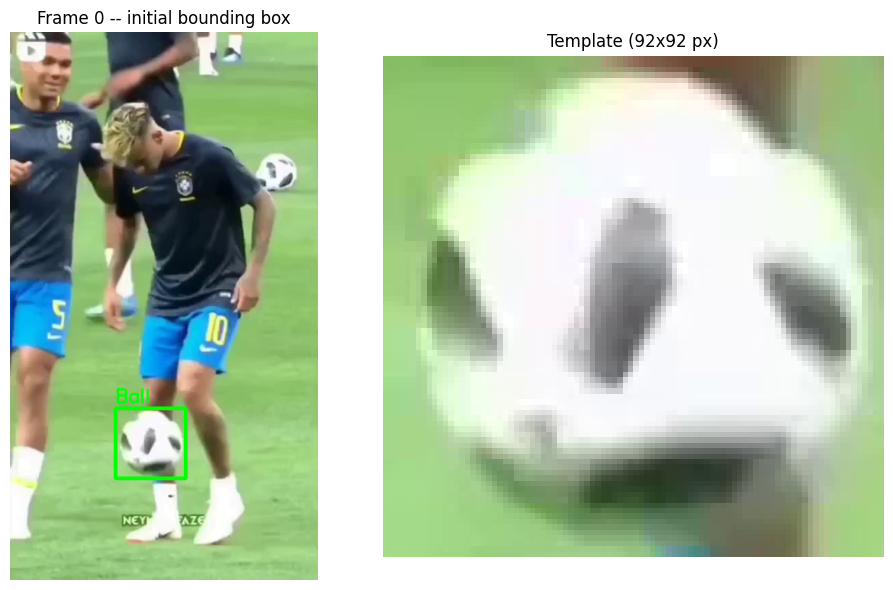

In [24]:
cap = cv2.VideoCapture('vid_cropped.mp4')
print(f'Total frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}')
print(f'FPS: {cap.get(cv2.CAP_PROP_FPS)}')
print(f'Size: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))} x {int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}')

N_FRAMES = 15
frames = []
for _ in range(N_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()
print(f'Frames loaded: {len(frames)}')

# Bounding box around the ball in frame 0 (x, y, w, h)
# Black bars removed; ball at centre-bottom of 404x720 frame
BBOX0 = (138, 494, 92, 92)

x0, y0, bw, bh = BBOX0
frame0_bgr = cv2.cvtColor(frames[0], cv2.COLOR_RGB2BGR)
template = frame0_bgr[y0:y0+bh, x0:x0+bw].copy()

vis0 = frames[0].copy()
cv2.rectangle(vis0, (x0, y0), (x0+bw, y0+bh), (0, 255, 0), 3)
cv2.putText(vis0, 'Ball', (x0, y0-8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(vis0)
axes[0].set_title('Frame 0 -- initial bounding box')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Template ({bw}x{bh} px)')
axes[1].axis('off')
plt.tight_layout()

### Step 2 — Initialise Tracker 1: MIL

**MIL (Multiple Instance Learning)** is an online discriminative tracker.
It samples positive bags (patches near the target) and negative bags (background patches)
and trains an online classifier using boosting with Haar-like features.
The model updates every frame, so it can adapt to appearance changes.

In [25]:
frame0_bgr = cv2.cvtColor(frames[0], cv2.COLOR_RGB2BGR)
tracker_mil = cv2.TrackerMIL_create()
tracker_mil.init(frame0_bgr, BBOX0)
print('MIL tracker initialised on frame 0')

MIL tracker initialised on frame 0


### Step 3 — Run MIL tracker for 15 frames

In [26]:
mil_boxes = [BBOX0]

for t in range(1, N_FRAMES):
    bgr = cv2.cvtColor(frames[t], cv2.COLOR_RGB2BGR)
    ok, bbox = tracker_mil.update(bgr)
    mil_boxes.append(tuple(int(v) for v in bbox) if ok else None)
    status = 'OK  ' if ok else 'LOST'
    print(f'Frame {t:2d} [{status}] MIL bbox: {mil_boxes[-1]}')

Frame  1 [OK  ] MIL bbox: (138, 494, 92, 92)
Frame  2 [OK  ] MIL bbox: (138, 494, 92, 92)
Frame  3 [OK  ] MIL bbox: (127, 472, 92, 92)
Frame  4 [OK  ] MIL bbox: (109, 459, 92, 92)
Frame  5 [OK  ] MIL bbox: (93, 440, 92, 92)
Frame  6 [OK  ] MIL bbox: (93, 416, 92, 92)
Frame  7 [OK  ] MIL bbox: (92, 416, 92, 92)
Frame  8 [OK  ] MIL bbox: (110, 417, 92, 92)
Frame  9 [OK  ] MIL bbox: (108, 441, 92, 92)
Frame 10 [OK  ] MIL bbox: (112, 421, 92, 92)
Frame 11 [OK  ] MIL bbox: (106, 408, 92, 92)
Frame 12 [OK  ] MIL bbox: (106, 407, 92, 92)
Frame 13 [OK  ] MIL bbox: (83, 411, 92, 92)
Frame 14 [OK  ] MIL bbox: (90, 415, 92, 92)


### Step 4 — Draw bounding boxes for MIL and save frames

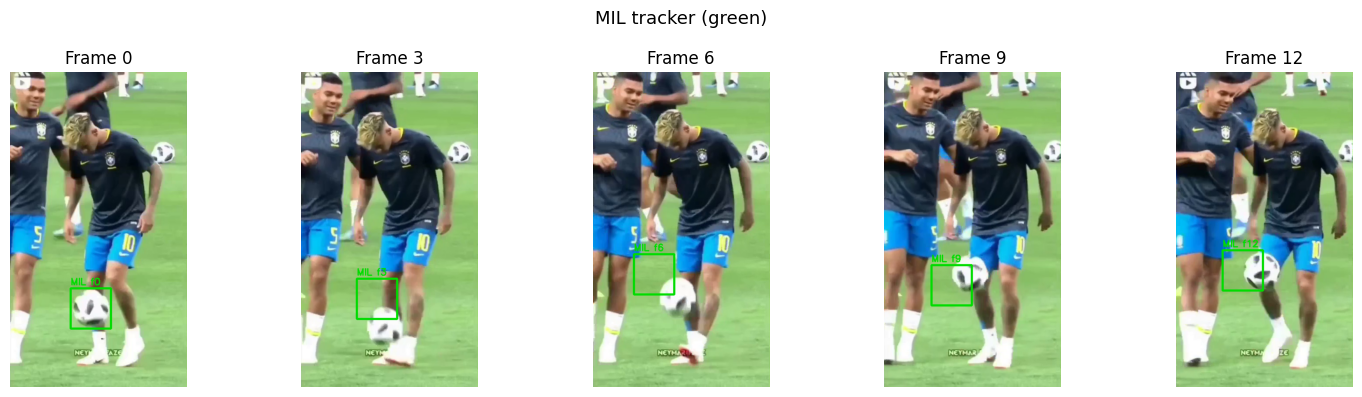

In [27]:
import os
os.makedirs('output_mil', exist_ok=True)

def draw_bbox(frame_rgb, bbox, color=(0,220,0), label=''):
    out = frame_rgb.copy()
    if bbox is not None:
        x, y, w, h = [int(v) for v in bbox]
        cv2.rectangle(out, (x,y), (x+w,y+h), color, 3)
        if label:
            cv2.putText(out, label, (x, max(y-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return out

show_idx = list(range(0, N_FRAMES, 3))
fig, axes = plt.subplots(1, len(show_idx), figsize=(15, 4))
for ax, t in zip(axes, show_idx):
    vis = draw_bbox(frames[t], mil_boxes[t], color=(0,220,0), label=f'MIL f{t}')
    ax.imshow(vis)
    ax.set_title(f'Frame {t}')
    ax.axis('off')
    cv2.imwrite(f'output_mil/frame_{t:02d}.jpg', cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
plt.suptitle('MIL tracker (green)', fontsize=13)
plt.tight_layout()

### Step 5 — Tracker 2: Template Matching (SAD)

**Template matching** slides the original template patch over every position in the new frame
and picks the location with the lowest *Sum of Squared Differences* (normalised).
Unlike MIL, the template is **fixed** — it never updates.

Frame  1  TM  bbox: (138, 494, 92, 92)
Frame  2  TM  bbox: (138, 494, 92, 92)
Frame  3  TM  bbox: (145, 535, 92, 92)
Frame  4  TM  bbox: (101, 533, 92, 92)
Frame  5  TM  bbox: (139, 492, 92, 92)
Frame  6  TM  bbox: (89, 539, 92, 92)
Frame  7  TM  bbox: (89, 539, 92, 92)
Frame  8  TM  bbox: (205, 593, 92, 92)
Frame  9  TM  bbox: (205, 603, 92, 92)
Frame 10  TM  bbox: (105, 536, 92, 92)
Frame 11  TM  bbox: (0, 587, 92, 92)
Frame 12  TM  bbox: (0, 587, 92, 92)
Frame 13  TM  bbox: (145, 418, 92, 92)
Frame 14  TM  bbox: (11, 626, 92, 92)


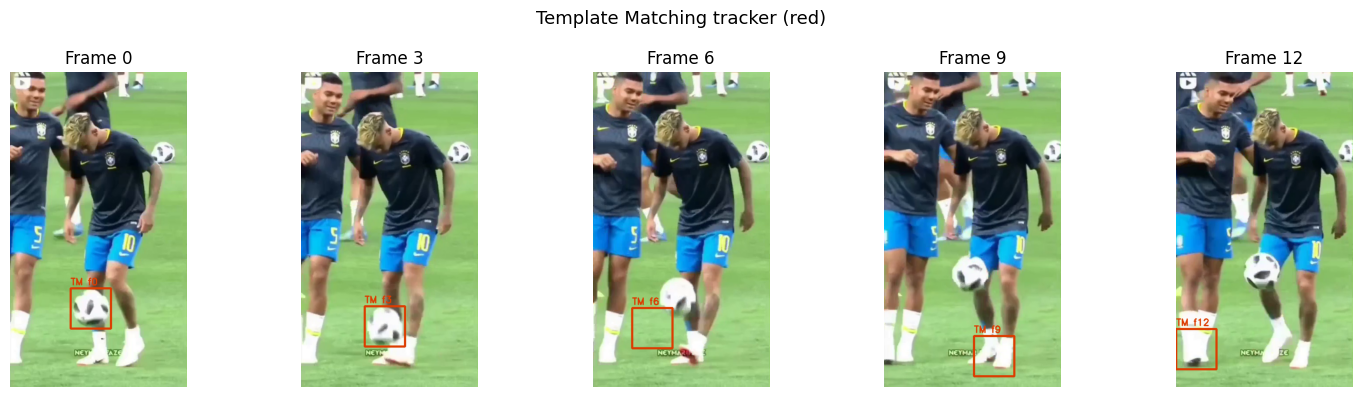

In [28]:
os.makedirs('output_tm', exist_ok=True)

def track_template(frames_rgb, bbox0, tmpl_bgr):
    boxes = [bbox0]
    bw, bh = bbox0[2], bbox0[3]
    tmpl_gray = cv2.cvtColor(tmpl_bgr, cv2.COLOR_BGR2GRAY)
    for t in range(1, len(frames_rgb)):
        frame_bgr = cv2.cvtColor(frames_rgb[t], cv2.COLOR_RGB2BGR)
        frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        result = cv2.matchTemplate(frame_gray, tmpl_gray, cv2.TM_SQDIFF_NORMED)
        _, _, min_loc, _ = cv2.minMaxLoc(result)
        boxes.append((min_loc[0], min_loc[1], bw, bh))
        print(f'Frame {t:2d}  TM  bbox: {boxes[-1]}')
    return boxes

tm_boxes = track_template(frames, BBOX0, template)

fig, axes = plt.subplots(1, len(show_idx), figsize=(15, 4))
for ax, t in zip(axes, show_idx):
    vis = draw_bbox(frames[t], tm_boxes[t], color=(220,60,0), label=f'TM f{t}')
    ax.imshow(vis)
    ax.set_title(f'Frame {t}')
    ax.axis('off')
    cv2.imwrite(f'output_tm/frame_{t:02d}.jpg', cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
plt.suptitle('Template Matching tracker (red)', fontsize=13)
plt.tight_layout()

### Step 6 — Side-by-side comparison

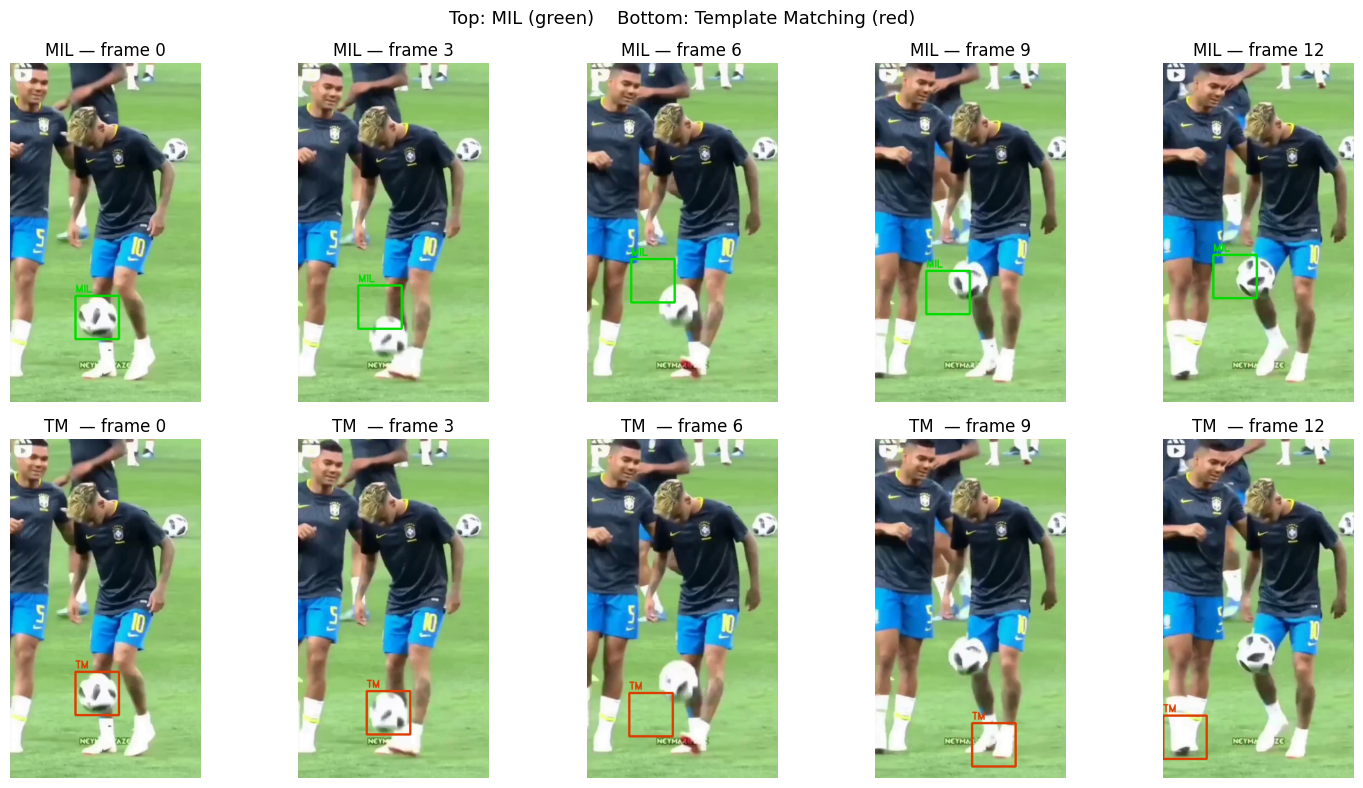

In [29]:
fig, axes = plt.subplots(2, len(show_idx), figsize=(15, 8))

for col, t in enumerate(show_idx):
    mil_vis = draw_bbox(frames[t], mil_boxes[t], color=(0,220,0),  label='MIL')
    tm_vis  = draw_bbox(frames[t], tm_boxes[t],  color=(220,60,0), label='TM')

    axes[0, col].imshow(mil_vis)
    axes[0, col].set_title(f'MIL — frame {t}')
    axes[0, col].axis('off')

    axes[1, col].imshow(tm_vis)
    axes[1, col].set_title(f'TM  — frame {t}')
    axes[1, col].axis('off')

plt.suptitle('Top: MIL (green)    Bottom: Template Matching (red)', fontsize=13)
plt.tight_layout()

**Observations & Comparison:**

| Property | MIL | Template Matching (SAD) |
|---|---|---|
| Model update | Online — re-trains each frame | Static — template fixed at frame 0 |
| Adapts to appearance | Yes (rotation, lighting) | No — assumes object looks the same |
| Occlusion handling | Degrades gracefully | Fails — keeps matching original patch |
| Speed | Moderate | Very fast |
| Scale change | Fixed box size | Fixed box size |

**Results on the football clip:**
- The ball is being juggled, so it moves rapidly and the black pentagon pattern rotates each frame.
- **MIL** adapts to the spinning ball and tends to stay closer to the actual ball position because it updates its classifier online.
- **Template Matching** degrades faster as the ball rotates: the stored template no longer matches the current view, causing drift toward other white regions in the scene.
- Both trackers can lose the ball briefly when it is partially occluded by the player's foot or leg.
- Overall, **MIL is more robust** for real video with dynamic appearance change, at the cost of slightly higher computation.